# Feature Engineering

Les données brutes contiennent : `secs`, `km`, `power`, `hr`, `cad`, `alt`.

Le problème c'est que ces colonnes seules ne sont pas suffisantes pour bien prédire la puissance.
On va donc créer de nouvelles variables à partir de ces données :

1. **Vitesse** (km/h) — calculée depuis la distance
2. **Pente** (%) — calculée depuis l'altitude et la distance
3. **Accélération** — dérivée de la vitesse
4. **Dérivée de la FC** — pour capturer l'inertie cardiaque
5. **Moyennes glissantes** sur 5 secondes — pour lisser le signal

Ensuite on sauvegarde tout dans `data/processed_dataset.csv`.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_folder = '../data/'

# On récupère la liste de tous les fichiers CSV de sorties
# On exclut processed_dataset.csv qui est le fichier de sortie qu'on va créer
fichiers_csv = sorted([
    f for f in os.listdir(data_folder)
    if f.endswith('.csv') and f != 'processed_dataset.csv'
])
print(f'{len(fichiers_csv)} fichiers trouvés')

In [2]:
def calculer_features(df, ride_id):
    """
    Prend un DataFrame d'une sortie et retourne un DataFrame enrichi
    avec toutes les features calculées.
    """
    # On travaille sur une copie pour ne pas modifier l'original
    d = df.copy()
    d['ride_id'] = ride_id

    # --- Vitesse en km/h ---
    # diff() donne la différence entre deux lignes consécutives
    delta_km = d['km'].diff().fillna(0)
    delta_secs = d['secs'].diff().fillna(1)  # on met 1 pour éviter la division par zéro
    delta_secs = delta_secs.replace(0, 1)
    d['vitesse_kmh'] = (delta_km / delta_secs) * 3600
    # On clamp les valeurs aberrantes (vitesse négative ou trop élevée)
    d['vitesse_kmh'] = d['vitesse_kmh'].clip(0, 120)

    # --- Pente en % ---
    # pente = dénivelé (m) / distance (m) * 100
    delta_alt = d['alt'].diff().fillna(0)
    delta_m = delta_km * 1000  # conversion km -> m
    # On évite la division par zéro quand le cycliste est arrêté
    d['pente_pct'] = np.where(delta_m > 0, (delta_alt / delta_m) * 100, 0)
    # On clamp pour éviter les valeurs impossibles
    d['pente_pct'] = d['pente_pct'].clip(-30, 30)

    # --- Accélération en km/h par seconde ---
    d['acceleration'] = d['vitesse_kmh'].diff().fillna(0)
    d['acceleration'] = d['acceleration'].clip(-10, 10)

    # --- Dérivée de la fréquence cardiaque ---
    # Cela capture l'inertie cardiaque (la FC monte après l'effort)
    d['delta_hr'] = d['hr'].diff().fillna(0)
    d['delta_hr'] = d['delta_hr'].clip(-10, 10)

    # --- Moyennes glissantes sur 5 secondes ---
    # min_periods=1 pour ne pas avoir de NaN au début
    d['vitesse_moy_5s'] = d['vitesse_kmh'].rolling(window=5, min_periods=1).mean()
    d['hr_moy_5s'] = d['hr'].rolling(window=5, min_periods=1).mean()
    d['cad_moy_5s'] = d['cad'].rolling(window=5, min_periods=1).mean()
    d['pente_moy_5s'] = d['pente_pct'].rolling(window=5, min_periods=1).mean()

    return d

print('Fonction définie OK')

Fonction définie OK


In [3]:
# On applique la fonction sur tous les fichiers
# Cela peut prendre quelques secondes

liste_df_enrichis = []

for i, fichier in enumerate(fichiers_csv):
    chemin = os.path.join(data_folder, fichier)
    df_temp = pd.read_csv(chemin)
    ride_id = fichier.replace('.csv', '')
    
    df_enrichi = calculer_features(df_temp, ride_id)
    liste_df_enrichis.append(df_enrichi)

    if (i + 1) % 20 == 0:
        print(f'Traitement en cours... {i+1}/{len(fichiers_csv)}')

df_final = pd.concat(liste_df_enrichis, ignore_index=True)
print(f'\nDataset final : {df_final.shape[0]} lignes, {df_final.shape[1]} colonnes')
df_final.head()

Traitement en cours... 20/164
Traitement en cours... 40/164
Traitement en cours... 60/164
Traitement en cours... 80/164
Traitement en cours... 100/164
Traitement en cours... 120/164
Traitement en cours... 140/164
Traitement en cours... 160/164

Dataset final : 3240910 lignes, 15 colonnes


,secs,km,power,hr,cad,alt,ride_id,vitesse_kmh,pente_pct,acceleration,delta_hr,vitesse_moy_5s,hr_moy_5s,cad_moy_5s,pente_moy_5s
0,0,0.00000,0,90,0,11.2,1,0.000,0.0,0.000,0.0,0.0000,90.0,0.0,0.0
1,1,0.00348,0,91,0,11.2,1,12.528,0.0,10.000,1.0,6.2640,90.5,0.0,0.0
2,2,0.00675,0,92,0,11.2,1,11.772,0.0,-0.756,1.0,8.1000,91.0,0.0,0.0
3,3,0.00978,0,93,0,11.2,1,10.908,0.0,-0.864,1.0,8.8020,91.5,0.0,0.0
4,4,0.01312,0,95,0,11.2,1,12.024,0.0,1.116,2.0,9.4464,92.2,0.0,0.0


In [4]:
# Vérification des nouvelles colonnes
print('Colonnes disponibles :', list(df_final.columns))
print()
df_final.describe().round(2)

Colonnes disponibles : ['secs', 'km', 'power', 'hr', 'cad', 'alt', 'ride_id', 'vitesse_kmh', 'pente_pct', 'acceleration', 'delta_hr', 'vitesse_moy_5s', 'hr_moy_5s', 'cad_moy_5s', 'pente_moy_5s']



,secs,km,power,hr,cad,alt,vitesse_kmh,pente_pct,acceleration,delta_hr,vitesse_moy_5s,hr_moy_5s,cad_moy_5s,pente_moy_5s
count,3240910.00,3240910.00,3240910.00,3240910.00,3240910.00,3240910.00,3240910.00,3240910.00,3240910.00,3240910.00,3240910.00,3240910.00,3240910.00,3240910.00
mean,6974.18,48.50,191.73,144.91,74.76,626.46,29.15,1.15,-0.01,0.01,29.15,144.91,74.76,1.15
std,5399.84,34.74,110.57,27.61,28.84,581.20,11.58,4.56,1.75,0.91,11.18,27.35,26.33,4.11
min,0.00,0.00,0.00,0.00,0.00,-86.40,0.00,-30.00,-10.00,-10.00,0.00,0.00,0.00,-30.00
25%,2768.00,20.41,137.00,128.00,71.00,86.20,21.24,0.00,-0.36,0.00,21.17,127.60,69.80,-0.54
50%,5755.00,42.47,205.00,147.00,85.00,410.40,28.80,0.00,0.00,0.00,28.80,146.80,84.00,0.44
75%,9792.00,70.97,260.00,165.00,91.00,1159.60,34.92,3.28,0.36,0.00,34.85,165.20,91.00,3.32
max,30221.00,179.89,1250.00,205.00,254.00,2378.20,120.00,30.00,10.00,10.00,120.00,205.00,205.60,30.00


In [5]:
# Vérification : nombre de NaN après feature engineering
print('NaN par colonne :')
print(df_final.isnull().sum())

NaN par colonne :
secs              0
km                0
power             0
hr                0
cad               0
alt               0
ride_id           0
vitesse_kmh       0
pente_pct         0
acceleration      0
delta_hr          0
vitesse_moy_5s    0
hr_moy_5s         0
cad_moy_5s        0
pente_moy_5s      0
dtype: int64


In [6]:
# On supprime les lignes avec NaN s'il y en a
avant = len(df_final)
df_final = df_final.dropna()
apres = len(df_final)
print(f'Lignes supprimées (NaN) : {avant - apres}')
print(f'Lignes restantes : {apres}')

Lignes supprimées (NaN) : 0
Lignes restantes : 3240910


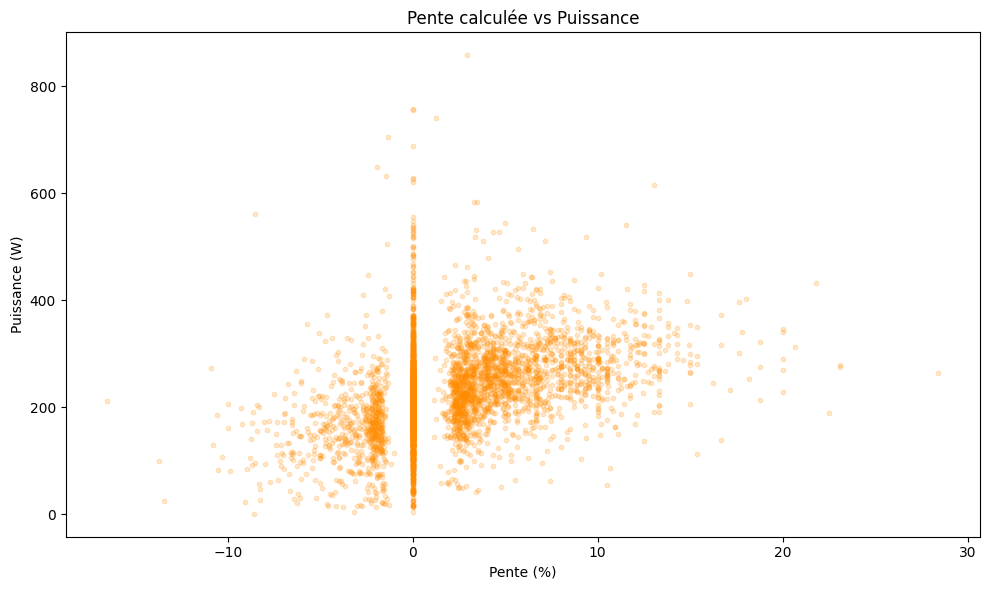

In [7]:
# Visualisation : la pente calculée vs la puissance
df_actif = df_final[df_final['power'] > 0]
echantillon = df_actif.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(echantillon['pente_pct'], echantillon['power'], alpha=0.2, color='darkorange', s=10)
plt.title('Pente calculée vs Puissance')
plt.xlabel('Pente (%)')
plt.ylabel('Puissance (W)')
plt.tight_layout()
plt.savefig('../plots/pente_vs_power.png')
plt.show()

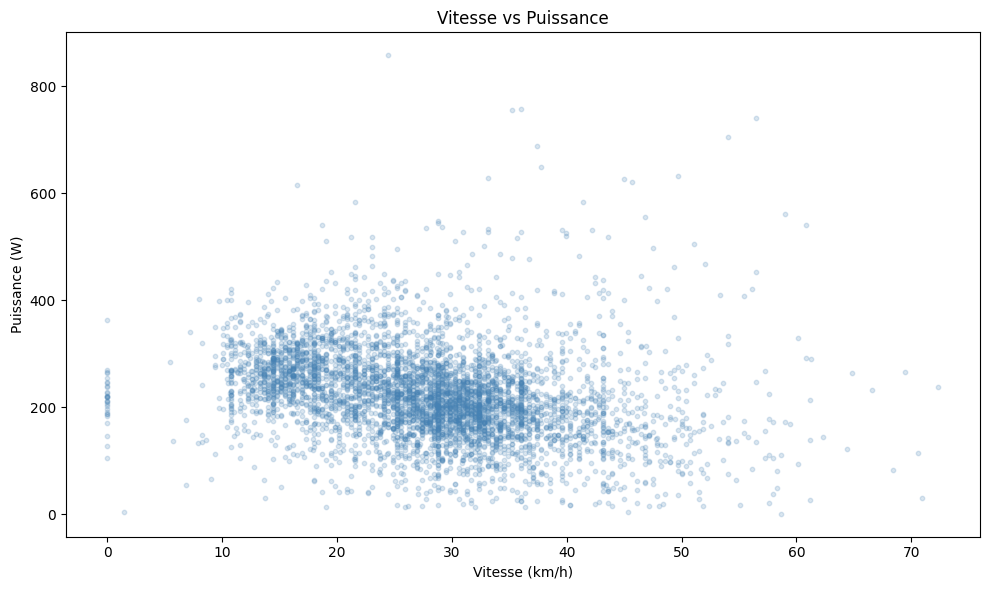

In [8]:
# Visualisation : vitesse vs puissance
plt.figure(figsize=(10, 6))
plt.scatter(echantillon['vitesse_kmh'], echantillon['power'], alpha=0.2, color='steelblue', s=10)
plt.title('Vitesse vs Puissance')
plt.xlabel('Vitesse (km/h)')
plt.ylabel('Puissance (W)')
plt.tight_layout()
plt.savefig('../plots/vitesse_vs_power.png')
plt.show()

In [9]:
# Sauvegarde du dataset final
chemin_sortie = '../data/processed_dataset.csv'
df_final.to_csv(chemin_sortie, index=False)
print(f'Dataset sauvegardé : {chemin_sortie}')
print(f'Taille : {df_final.shape}')
print(f'Colonnes : {list(df_final.columns)}')

Dataset sauvegardé : ../data/processed_dataset.csv
Taille : (3240910, 15)
Colonnes : ['secs', 'km', 'power', 'hr', 'cad', 'alt', 'ride_id', 'vitesse_kmh', 'pente_pct', 'acceleration', 'delta_hr', 'vitesse_moy_5s', 'hr_moy_5s', 'cad_moy_5s', 'pente_moy_5s']


## Résumé des features créées

| Feature | Description |
|---------|-------------|
| `vitesse_kmh` | Vitesse instantanée calculée depuis la distance |
| `pente_pct` | Pente en % calculée depuis l'altitude et la distance |
| `acceleration` | Variation de vitesse par seconde |
| `delta_hr` | Variation de FC par seconde (inertie cardiaque) |
| `vitesse_moy_5s` | Moyenne glissante de la vitesse sur 5 secondes |
| `hr_moy_5s` | Moyenne glissante de la FC sur 5 secondes |
| `cad_moy_5s` | Moyenne glissante de la cadence sur 5 secondes |
| `pente_moy_5s` | Moyenne glissante de la pente sur 5 secondes |

**Prochaine étape** : entraîner les modèles sur ce dataset.